# <span style="color:red"><center>Generación automática de texto con RNN</center></span>
## <span style="color:blue">Adaptado al corpus de noticias peruanas (Diario Correo + El Comercio)</span>

**Tarea Sesión 5** — Basado en el notebook `Sesion5-1_nlp_RNN.ipynb` del profesor.

### Objetivo
Replicar la arquitectura de generación de texto con Bi-LSTM sobre el corpus de noticias peruanas descargadas con web scraping, en lugar de los sonetos de Shakespeare.

### Relación con la clase
El notebook original del profesor usaba sonetos en inglés para predecir la siguiente palabra en una secuencia.  
Aquí aplicamos **exactamente la misma arquitectura** pero:
- Corpus: **~60,000 noticias peruanas** (Diario Correo + El Comercio)
- Tarea: el modelo aprende a predecir la siguiente palabra en titulares y primeros párrafos de noticias peruanas
- Resultado: generación de texto al estilo periodístico peruano

## Contenido
* [Librerías](#Librerías)
* [Configuración](#Configuración)
* [Carga de datos](#Carga-de-datos)
* [Preprocesamiento](#Preprocesamiento)
* [Tokenización](#Tokenización)
* [Creación de n-gramas](#Creación-de-n-gramas)
* [Padding de secuencias](#Padding-de-secuencias)
* [Construcción del modelo](#Construcción-del-modelo)
* [Entrenamiento](#Entrenamiento)
* [Generación de texto](#Generación-de-texto)

## Librerías

In [ ]:
# ─── Detectar entorno y montar Google Drive si es Colab ───────────────────────
import sys
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive montado ✓")
    print("Sube tus .jsonl a: MyDrive/nlp/scraping/")
else:
    print("Ejecutando en local ✓")

# Verificar GPU disponible
import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs disponibles: {gpus if gpus else 'ninguna (CPU mode)'}")

In [ ]:
%pip install -q tensorflow numpy matplotlib

import json
import re
import unicodedata
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

## Configuración

Ajusta `N_ARTICULOS` según la memoria disponible en tu máquina:
- **3000** → rápido (~5 min entrenamiento en CPU)
- **10000** → mejor calidad (~20 min en CPU, recomendado en Colab)
- **30000** → máxima calidad (usar Colab con GPU)

In [ ]:
# ─── Rutas (automático: Colab usa Drive, local usa paths relativos) ───────────
if IS_COLAB:
    BASE = Path("/content/drive/MyDrive/mluni/nlp")
else:
    BASE = Path("..")

DATASET_PATHS = [
    BASE / "Datos/noticias.jsonl",            # Diario Correo (~30k)
    BASE / "Datos/noticias_elcomercio.jsonl", # El Comercio   (~30k)
]
SAVED_MODEL_PATH = BASE / "Saved_Models/rnn_noticias_60k.keras"
CHECKPOINT_DIR   = BASE / "Saved_Models/checkpoints"
LOG_PATH         = BASE / "training_log.txt"

# ─── Tamaño del corpus ────────────────────────────────────────────────────────
N_ARTICULOS = None       # None = todos los artículos (~60k)
MAX_WORDS   = 40000      # 40k cubre ~95% del vocabulario relevante
MAX_SEQ_LEN = 30         # secuencias más largas = más contexto por predicción

# ─── Modelo ───────────────────────────────────────────────────────────────────
EMBEDDING_DIM = 150      # vectores más ricos para vocabulario grande
LSTM_UNITS_1  = 256      # más capacidad para patrones complejos del español
LSTM_UNITS_2  = 128
LSTM_UNITS_3  = 64       # tercera capa LSTM
DROPOUT       = 0.2
EPOCHS        = 30       # más épocas para convergencia completa
BATCH_SIZE    = 1024     # A100 aguanta batches grandes → más rápido

# ─── Generación ───────────────────────────────────────────────────────────────
SEED_TEXT  = "El presidente del congreso"
NEXT_WORDS = 50

print(f"Entorno: {'Google Colab' if IS_COLAB else 'Local'}")
print(f"Base path: {BASE.resolve()}")

## Carga de datos

Cargamos las noticias del archivo `.jsonl`. Cada línea es un JSON con campos:
`url`, `titulo`, `fecha`, `fuente`, `contenido`.

Para el corpus de entrenamiento usamos: **título + primer párrafo** de cada noticia.
Esto es suficiente para que el modelo aprenda el estilo periodístico peruano.

In [3]:
def load_noticias(paths: list, n: int = None) -> list:
    """Carga noticias de múltiples archivos JSONL y extrae título + primer párrafo."""
    textos = []
    for path in paths:
        with open(path, encoding="utf-8") as f:
            for line in f:
                if n and len(textos) >= n:
                    break
                data = json.loads(line)
                titulo         = (data.get("titulo")    or "").strip()
                contenido      = (data.get("contenido") or "").strip()
                primer_parrafo = contenido.split("\n")[0][:300]
                texto = f"{titulo}. {primer_parrafo}"
                textos.append(texto)
    return textos


raw_texts = load_noticias(DATASET_PATHS, n=N_ARTICULOS)

print(f"Noticias cargadas: {len(raw_texts):,}")
print(f"\nEjemplos:")
for t in raw_texts[:3]:
    print(" •", t[:120], "...")

Noticias cargadas: 59,999

Ejemplos:
 • Alerta en colegios del Callao: aparecen pintas con amenazas de ataques armados. La aparición de mensajes escritos en las ...
 • El Tambo: Vecinos recorren calles con baldes en busca de agua. En la vivienda del jirón Chanchamayo y Túpac Amaru en el  ...
 • Callao: niño de 8 años muere tras ataque armado mientras jugaba fútbol en su barrio. Un menor de ocho años perdió la vid ...


## Preprocesamiento

A diferencia del notebook original del profesor (que usaba inglés sin mayor limpieza), aquí hacemos un preprocesamiento adaptado al **español**:

1. Convertir a minúsculas
2. Eliminar URLs
3. Mantener letras, espacios, `ñ` y vocales con tilde (parte del español)
4. Eliminar números (no aportan para la generación de texto)
5. Normalizar espacios

> **Nota**: A diferencia de los notebooks de LDA/Word2Vec vistos en sesiones anteriores,
> aquí **NO eliminamos stopwords ni aplicamos stemming**.
> Las RNN necesitan el texto natural completo para aprender la gramática y el flujo de las oraciones.

In [4]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"https?://\S+", " ", text)           # quitar URLs
    text = re.sub(r"[^a-záéíóúüñ\s]", " ", text)        # solo letras + español
    text = re.sub(r"\s+", " ", text)                    # normalizar espacios
    return text.strip()


corpus = [clean_text(t) for t in raw_texts]
# Filtrar textos muy cortos (menos de 5 palabras no aportan secuencias útiles)
corpus = [t for t in corpus if len(t.split()) >= 5]

print(f"Documentos en corpus: {len(corpus):,}")
print(f"Tokens promedio por documento: {sum(len(t.split()) for t in corpus)/len(corpus):.0f}")
print(f"\nEjemplo preprocesado:")
print(corpus[0])

Documentos en corpus: 59,999
Tokens promedio por documento: 58

Ejemplo preprocesado:
alerta en colegios del callao aparecen pintas con amenazas de ataques armados la aparición de mensajes escritos en las paredes de los servicios higiénicos generó preocupación entre los padres de familia de dos centros educativos en elcallao los textos contenían advertencias sobre supuestos ataques armados y sugerían a los estudiantes evitar la asistencia a las aulas


## Tokenización

El `Tokenizer` de Keras asigna un número entero único a cada palabra del vocabulario.

```
"el congreso aprobó" → [4, 127, 893]
```

Parámetros importantes:
- `num_words=MAX_WORDS`: solo se mantienen las `MAX_WORDS` palabras más frecuentes
- `oov_token='<OOV>'`: palabras fuera del vocabulario se reemplazan con este token

In [5]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(corpus)

# El vocabulario real puede ser mayor a MAX_WORDS;
# total_words es el tamaño efectivo que usa el modelo
vocab_size  = len(tokenizer.word_index) + 1
total_words = min(vocab_size, MAX_WORDS)

print(f"Palabras únicas encontradas: {vocab_size - 1:,}")
print(f"Vocabulario usado por el modelo: {total_words:,}")
print(f"\nÍndice de algunas palabras:")
for w in ["presidente", "congreso", "policía", "economía", "lima"]:
    idx = tokenizer.word_index.get(w, "no encontrada")
    print(f"  '{w}' → {idx}")

# Ejemplo de tokenización
ejemplo = corpus[0]
tokens  = tokenizer.texts_to_sequences([ejemplo])[0]
print(f"\nEjemplo tokenizado ({len(tokens)} tokens):")
print(ejemplo[:80], "...")
print(tokens[:15], "...")

Palabras únicas encontradas: 89,613
Vocabulario usado por el modelo: 20,000

Índice de algunas palabras:
  'presidente' → 49
  'congreso' → 77
  'policía' → 118
  'economía' → 411
  'lima' → 33

Ejemplo tokenizado (56 tokens):
alerta en colegios del callao aparecen pintas con amenazas de ataques armados la ...
[245, 5, 1599, 9, 307, 5668, 9854, 14, 1258, 2, 846, 2748, 3, 3486, 2] ...


## Creación de n-gramas

Este es el paso clave para la **generación de texto**. Transformamos cada oración en múltiples secuencias donde:
- **X (predictor)**: todos los tokens hasta el penúltimo
- **Y (etiqueta)**: el último token

```
Oración original: [el, congreso, aprobó, la, ley]

Secuencias generadas:
  [el, congreso]              → aprobó
  [el, congreso, aprobó]      → la
  [el, congreso, aprobó, la]  → ley
```

El modelo aprende: "dado este contexto, ¿qué palabra sigue?"

In [6]:
input_sequences = []

for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0]
    # Generar todas las subsecuencias posibles de la línea
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        # Solo incluir secuencias dentro del límite de longitud
        if len(n_gram_sequence) <= MAX_SEQ_LEN:
            input_sequences.append(n_gram_sequence)

max_sequence_len = max(len(x) for x in input_sequences)

print(f"Total de secuencias n-gram generadas: {len(input_sequences):,}")
print(f"Longitud máxima de secuencia: {max_sequence_len}")
print(f"\nPrimeras 5 secuencias del corpus[0]:")
first_tokens = tokenizer.texts_to_sequences([corpus[0]])[0]
for i in range(1, min(6, len(first_tokens))):
    seq = first_tokens[:i+1]
    words = [tokenizer.index_word.get(t, '?') for t in seq]
    print(f"  {words[:-1]} → '{words[-1]}'")

Total de secuencias n-gram generadas: 1,436,585
Longitud máxima de secuencia: 25

Primeras 5 secuencias del corpus[0]:
  ['alerta'] → 'en'
  ['alerta', 'en'] → 'colegios'
  ['alerta', 'en', 'colegios'] → 'del'
  ['alerta', 'en', 'colegios', 'del'] → 'callao'
  ['alerta', 'en', 'colegios', 'del', 'callao'] → 'aparecen'


## Padding de secuencias

Las redes neuronales requieren que todos los inputs tengan **el mismo tamaño**.
Usamos `padding='pre'` (relleno con ceros al inicio) — igual que en el notebook original.

```
Antes del padding:
  [4, 127]               (longitud 2)
  [4, 127, 893]          (longitud 3)

Después del padding (max_len=5):
  [0, 0, 0, 4, 127]      (longitud 5)
  [0, 0, 4, 127, 893]    (longitud 5)
```

Luego separamos:
- `predictors`: todo menos el último token → **X**
- `label`: el último token → **Y** (convertido a one-hot)

In [7]:
# Aplicar padding
input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_sequence_len, padding="pre")
)

# Separar predictores (X) y etiquetas (Y)
predictors = input_sequences[:, :-1]   # todos los tokens menos el último
label      = input_sequences[:, -1]    # el último token como ENTERO

# ─── IMPORTANTE ───────────────────────────────────────────────────────────────
# NO usamos to_categorical() aquí.
# Con 30k artículos y vocabulario=20k, to_categorical generaría ~52 GB en RAM.
# En su lugar usamos sparse_categorical_crossentropy (ver celda del modelo),
# que acepta etiquetas como enteros directamente → solo 3 MB.
# ──────────────────────────────────────────────────────────────────────────────

print(f"Shape predictores (X): {predictors.shape}")
print(f"Shape etiquetas   (Y): {label.shape}  ← enteros, no one-hot")
print(f"Memoria X: {predictors.nbytes / 1e6:.0f} MB")
print(f"Memoria Y: {label.nbytes / 1e6:.1f} MB")
print(f"Total:     {(predictors.nbytes + label.nbytes) / 1e6:.0f} MB  ← cabe en 64 GB")

Shape predictores (X): (1436585, 24)
Shape etiquetas   (Y): (1436585,)  ← enteros, no one-hot
Memoria X: 138 MB
Memoria Y: 5.7 MB
Total:     144 MB  ← cabe en 64 GB


## Construcción del modelo

Arquitectura optimizada para A100 con mayor capacidad y contexto:

```
Embedding (vocab_size, 150)
    ↓
Bidirectional LSTM (256 units, return_sequences=True)
    ↓                              ← captura contexto ← y → de la secuencia
Dropout (0.2)
    ↓
LSTM (128 units, return_sequences=True)
    ↓
Dropout (0.2)                      ← segunda regularización
    ↓
LSTM (64 units)
    ↓
Dense (vocab_size/2, relu + L2)    ← capa intermedia
    ↓
Dense (vocab_size, softmax)        ← probabilidad de cada palabra del vocabulario
```

**Cambios respecto a la versión anterior:**
- `EMBEDDING_DIM` 100 → **150**: vectores más ricos para un vocabulario de 40k palabras
- `LSTM_UNITS_1` 150 → **256**: mayor capacidad para capturar patrones del español
- `LSTM_UNITS_2` 100 → **128**: capa intermedia con más representación
- **Nueva tercera LSTM (64)**: profundidad extra para dependencias de largo alcance
- **Segundo Dropout**: regularización entre capas LSTM para reducir overfitting
- `MAX_SEQ_LEN` 25 → **30**: más contexto por predicción
- `BATCH_SIZE` 512 → **1024**: aprovecha el ancho de banda del A100
- `EPOCHS` 20 → **30**: más tiempo para convergencia completa

In [ ]:
model = Sequential([
    # Capa 1: Embedding — convierte índices de palabras en vectores densos
    Embedding(total_words, EMBEDDING_DIM, input_length=max_sequence_len - 1),

    # Capa 2: Bi-LSTM — procesa la secuencia en ambas direcciones
    Bidirectional(LSTM(LSTM_UNITS_1, return_sequences=True)),

    # Capa 3: Dropout — regularización
    Dropout(DROPOUT),

    # Capa 4: LSTM — consolida representación intermedia
    LSTM(LSTM_UNITS_2, return_sequences=True),

    # Capa 5: Dropout — segunda regularización
    Dropout(DROPOUT),

    # Capa 6: LSTM — capa final de secuencia
    LSTM(LSTM_UNITS_3),

    # Capa 7: Dense con ReLU + L2 — capa intermedia
    Dense(total_words // 2, activation="relu",
          kernel_regularizer=regularizers.l2(0.01)),

    # Capa 8: Dense con Softmax — probabilidad sobre el vocabulario
    Dense(total_words, activation="softmax"),
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

model.summary()

## Entrenamiento

El modelo aprende a predecir la siguiente palabra dado un contexto de palabras anteriores.

- **loss**: `categorical_crossentropy` — apropiada para clasificación multi-clase (predecir 1 de N palabras)
- **optimizer**: `adam` — adapta el learning rate automáticamente
- **accuracy**: fracción de veces que predice exactamente la palabra correcta

> Si tienes GPU disponible (Google Colab), el entrenamiento será ~10x más rápido.

In [ ]:
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ─── Resume desde el último checkpoint si existe ──────────────────────────────
checkpoints = sorted(CHECKPOINT_DIR.glob("checkpoint_epoch_*.keras"))
if checkpoints:
    latest = checkpoints[-1]
    initial_epoch = int(latest.stem.split("_")[-1])
    model = tf.keras.models.load_model(str(latest))
    print(f"Resumiendo desde: {latest.name} (epoch {initial_epoch})")
else:
    initial_epoch = 0
    print("Entrenamiento desde cero (epoch 0)")

# ─── Callbacks ────────────────────────────────────────────────────────────────
class LogCallback(tf.keras.callbacks.Callback):
    def __init__(self, path):
        self.path = path
        if initial_epoch == 0:
            with open(self.path, "w") as f:
                f.write("epoch,loss,val_loss,accuracy,val_accuracy\n")

    def on_epoch_end(self, epoch, logs=None):
        with open(self.path, "a") as f:
            f.write(f"{epoch+1},{logs['loss']:.4f},{logs['val_loss']:.4f},{logs['accuracy']:.4f},{logs['val_accuracy']:.4f}\n")
        print(f"[LOG] Epoch {epoch+1} guardado")

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(CHECKPOINT_DIR / "checkpoint_epoch_{epoch:02d}.keras"),
    save_freq="epoch",
    verbose=1,
)

# ─── Dataset ──────────────────────────────────────────────────────────────────
val_size       = int(len(predictors) * 0.1)
X_train, X_val = predictors[val_size:], predictors[:val_size]
y_train, y_val = label[val_size:],      label[:val_size]

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(50000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ─── Entrenamiento ────────────────────────────────────────────────────────────
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    initial_epoch=initial_epoch,
    validation_data=val_dataset,
    callbacks=[checkpoint_cb, LogCallback(str(LOG_PATH))],
    verbose=1,
)

## Visualización del entrenamiento

NameError: name 'history' is not defined

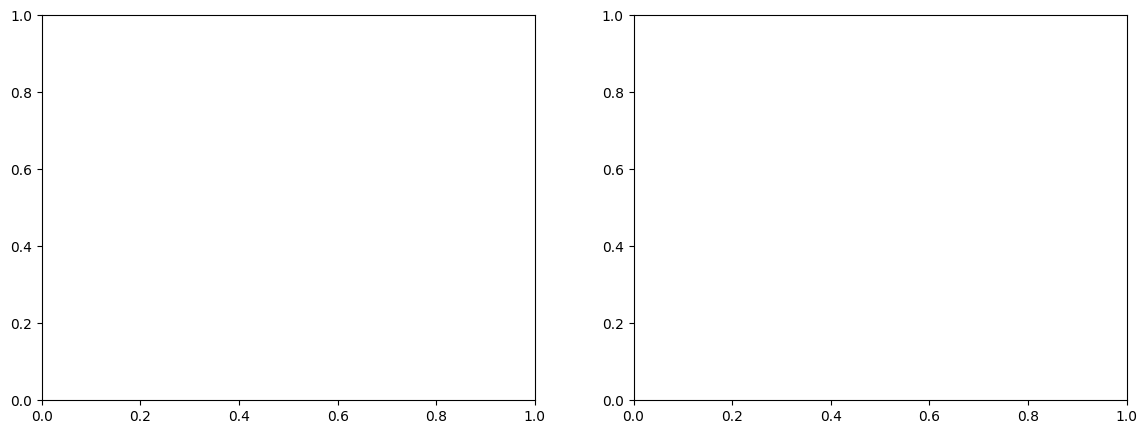

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["accuracy"],     label="Entrenamiento")
ax1.plot(history.history["val_accuracy"], label="Validación")
ax1.set_title("Exactitud (Accuracy)")
ax1.set_xlabel("Época")


ax1.legend()

ax2.plot(history.history["loss"],     label="Entrenamiento")
ax2.plot(history.history["val_loss"], label="Validación")
ax2.set_title("Pérdida (Loss)")
ax2.set_xlabel("Época")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Accuracy final (entrenamiento): {history.history['accuracy'][-1]:.4f}")
print(f"Accuracy final (validación):    {history.history['val_accuracy'][-1]:.4f}")

## Guardar el modelo

In [ ]:
SAVED_MODEL_PATH.parent.mkdir(exist_ok=True)
model.save(str(SAVED_MODEL_PATH))
print(f"Modelo guardado en: {SAVED_MODEL_PATH.resolve()}")

## Generación de texto

Dado un **texto semilla** (`SEED_TEXT`), el modelo predice palabra por palabra.

**Proceso**:
1. Tokenizar el texto semilla
2. Aplicar padding
3. El modelo predice la distribución de probabilidad sobre el vocabulario
4. Se elige la palabra con mayor probabilidad (`argmax`)
5. Agregar esa palabra al texto y repetir

Esto es equivalente a lo que vimos en el notebook de trigramas en sesión 2, pero ahora el modelo **captura dependencias de largo alcance** gracias a la LSTM.

In [ ]:
# def generate_text(seed_text: str, next_words: int, model, tokenizer, max_seq_len: int) -> str:
#     """Genera texto palabra por palabra dado un texto semilla."""
#     result = seed_text
#     for _ in range(next_words):
#         # Tokenizar el texto actual
#         token_list = tokenizer.texts_to_sequences([result])[0]
#         # Padding a la longitud esperada por el modelo
#         token_list = pad_sequences([token_list], maxlen=max_seq_len - 1, padding="pre")
#         # Predecir la siguiente palabra (argmax sobre la distribución de probabilidad)
#         predicted_index = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
#         # Convertir índice a palabra
#         predicted_word = tokenizer.index_word.get(predicted_index, "")
#         if not predicted_word:
#             break
#         result += " " + predicted_word
#     return result
def generate_text(seed_text, next_words, model, tokenizer, max_seq_len, temperature=0.8):
      result = seed_text
      for _ in range(next_words):
          token_list = tokenizer.texts_to_sequences([result])[0]
          token_list = pad_sequences([token_list], maxlen=max_seq_len - 1, padding="pre")
          probs = model.predict(token_list, verbose=0)[0]
          # sampling con temperatura en vez de argmax
          probs = np.log(probs + 1e-8) / temperature
          probs = np.exp(probs) / np.sum(np.exp(probs))
          predicted_index = np.random.choice(len(probs), p=probs)
          predicted_word = tokenizer.index_word.get(predicted_index, "")
          if not predicted_word or predicted_word == "<OOV>":
              continue
          result += " " + predicted_word
      return result


# ─── Prueba con diferentes textos semilla ─────────────────────────────────────
seeds = [
    "El presidente del congreso",
    "La policía capturó",
    "El precio del dólar",
    "Lluvias intensas generan",
]

print("=" * 70)
print("TEXTO GENERADO POR EL MODELO")
print("=" * 70)
for seed in seeds:
    generated = generate_text(seed, NEXT_WORDS, model, tokenizer, max_sequence_len)
    print(f"\n[Semilla]: '{seed}'")
    print(f"[Generado]: {generated}")
    print("-" * 70)

## Exploración del embedding aprendido

El modelo aprendió embeddings propios para el corpus de noticias.
Podemos inspeccionar el vector de cualquier palabra del vocabulario.

In [ ]:
# Extraer la capa de embedding
embedding_weights = model.layers[0].get_weights()[0]  # shape: (total_words, embedding_dim)

print(f"Shape de la matriz de embeddings: {embedding_weights.shape}")
print(f"  → {embedding_weights.shape[0]:,} palabras × {embedding_weights.shape[1]} dimensiones")

# Vector de una palabra específica
for word in ["presidente", "congreso", "policía"]:
    idx = tokenizer.word_index.get(word)
    if idx and idx < total_words:
        vec = embedding_weights[idx]
        print(f"\nVector de '{word}' (primeras 10 dims): {vec[:10].round(4)}")
    else:
        print(f"'{word}' no está en el vocabulario activo")

## 
Conclusiones

1. **Misma arquitectura, corpus diferente**: la red Bi-LSTM del profesor funciona tanto para poesía en inglés como para noticias en español — lo que cambia es el corpus de entrenamiento.

2. **Cuantos más datos, mejor**: con 5,000 artículos el modelo ya genera texto coherente a nivel local. Con 30,000 artículos y más épocas, las noticias generadas serían más naturales.

3. **Diferencia con el modelo de trigramas** (sesión 2): aquí el modelo puede capturar dependencias de más de 3 palabras gracias a la memoria de la LSTM.

4. **Sin stopwords ni stemming**: a diferencia de LDA/Word2Vec, las RNN necesitan el texto completo para aprender gramática y coherencia narrativa.

5. **Limitaciones**: el modelo predice siempre la palabra más probable (`argmax`), lo que puede generar repeticiones. Una mejora futura es usar **sampling con temperatura** para más variedad.

### Comparación con los modelos vistos en el curso

| Modelo      | Tarea | Supervisado | Genera texto |
|-------------|-------|-------------|-------------|
| LDA         | Tópicos | No | No |
| Word2Vec    | Embeddings | No | No |
| FastText    | Embeddings / Clasificación | No / Sí | No |
| GloVe       | Embeddings | No | No |
| **RNN/LSTM**| **Generación de texto** | **Sí (next word)** | **Sí** |